<a href="https://colab.research.google.com/github/Anaya2306/HackoWeek-SEM-5/blob/main/Week_13_%26_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install libraries (LightGBM and XGBoost come pre-installed in Colab, but upgrading ensures compatibility)
!pip install -q xgboost lightgbm scikit-learn matplotlib seaborn pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification, make_regression, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import Ridge, Lasso, LogisticRegression

import xgboost as xgb
import lightgbm as lgb

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
print("Libraries imported successfully!")

Libraries imported successfully!


Bias-Variance Trade-off

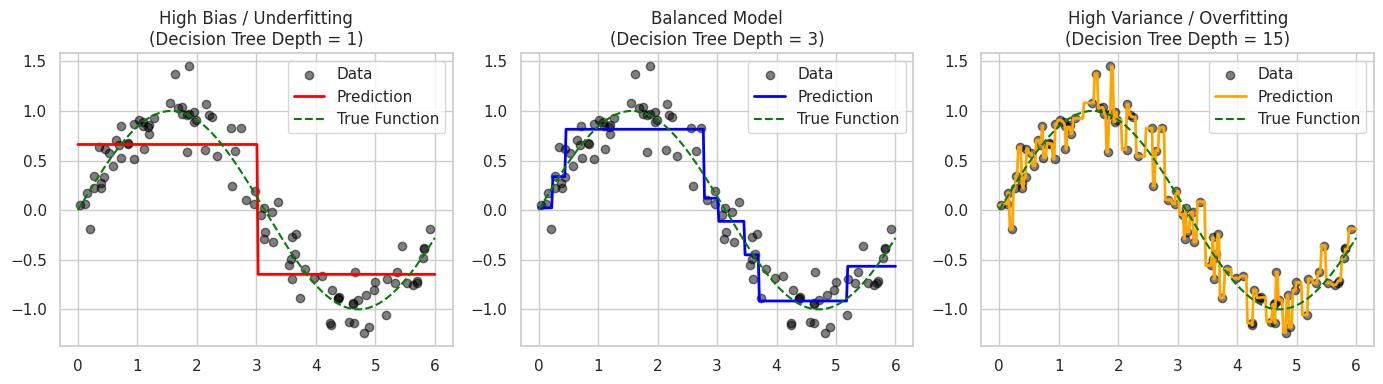

In [2]:
# Generate a noisy non-linear dataset: y = sin(x) + noise
np.random.seed(42)
X = np.sort(np.random.rand(100, 1) * 6, axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])

X_test = np.linspace(0, 6, 300).reshape(-1, 1)
y_true = np.sin(X_test).ravel()

plt.figure(figsize=(14, 4))

# 1. High Bias (Underfitting): Tree depth = 1
tree_underfit = DecisionTreeClassifier(max_depth=1) # using Regressor logic via DecisionTree
from sklearn.tree import DecisionTreeRegressor
tree_underfit = DecisionTreeRegressor(max_depth=1).fit(X, y)
y_pred_under = tree_underfit.predict(X_test)

plt.subplot(1, 3, 1)
plt.scatter(X, y, color="black", label="Data", alpha=0.5)
plt.plot(X_test, y_pred_under, color="red", linewidth=2, label="Prediction")
plt.plot(X_test, y_true, color="green", linestyle="--", label="True Function")
plt.title("High Bias / Underfitting\n(Decision Tree Depth = 1)")
plt.legend()

# 2. Balanced Model: Tree depth = 3
tree_balanced = DecisionTreeRegressor(max_depth=3).fit(X, y)
y_pred_bal = tree_balanced.predict(X_test)

plt.subplot(1, 3, 2)
plt.scatter(X, y, color="black", label="Data", alpha=0.5)
plt.plot(X_test, y_pred_bal, color="blue", linewidth=2, label="Prediction")
plt.plot(X_test, y_true, color="green", linestyle="--", label="True Function")
plt.title("Balanced Model\n(Decision Tree Depth = 3)")
plt.legend()

# 3. High Variance (Overfitting): Tree depth = 15
tree_overfit = DecisionTreeRegressor(max_depth=15).fit(X, y)
y_pred_over = tree_overfit.predict(X_test)

plt.subplot(1, 3, 3)
plt.scatter(X, y, color="black", label="Data", alpha=0.5)
plt.plot(X_test, y_pred_over, color="orange", linewidth=2, label="Prediction")
plt.plot(X_test, y_true, color="green", linestyle="--", label="True Function")
plt.title("High Variance / Overfitting\n(Decision Tree Depth = 15)")
plt.legend()

plt.tight_layout()
plt.show()

Overfitting, Underfitting and learning curve

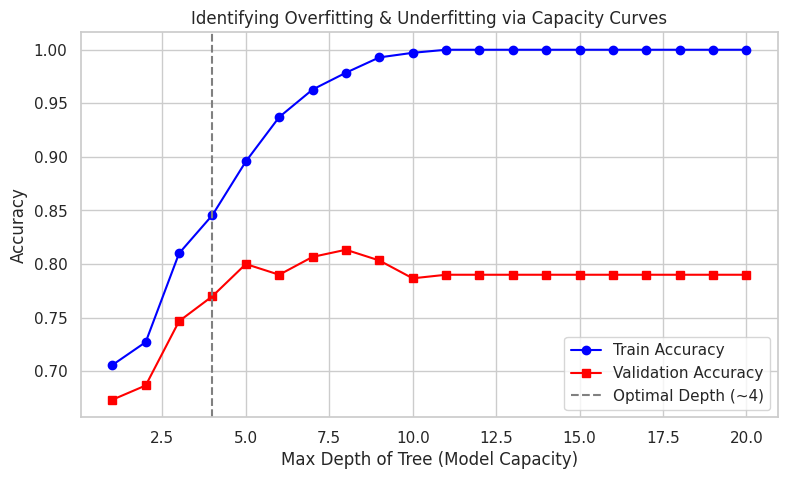

In [4]:
# Demonstrate Overfitting vs Underfitting across Tree Depths
X_data, y_data = make_classification(n_samples=1000, n_features=20, n_informative=15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

depths = range(1, 21)
train_acc = []
val_acc = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, clf.predict(X_train)))
    val_acc.append(accuracy_score(y_val, clf.predict(X_val)))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_acc, label="Train Accuracy", color="blue", marker="o")
plt.plot(depths, val_acc, label="Validation Accuracy", color="red", marker="s")
plt.axvline(x=4, color="gray", linestyle="--", label="Optimal Depth (~4)")
plt.xlabel("Max Depth of Tree (Model Capacity)")
plt.ylabel("Accuracy")
plt.title("Identifying Overfitting & Underfitting via Capacity Curves")
plt.legend()
plt.show()

Regularization

--- Coefficients Comparison ---
   L1 (Lasso) Coefs  L2 (Ridge) Coefs
0         16.845868         17.970654
1         54.440816         48.283870
2          0.835940          4.040407
3         63.544662         56.774960
4         88.014749         76.854131
5         65.939679         58.789061
6         80.886068         74.235844
7          2.733479          1.045860
8          0.172937          2.521908
9         67.806907         57.961532


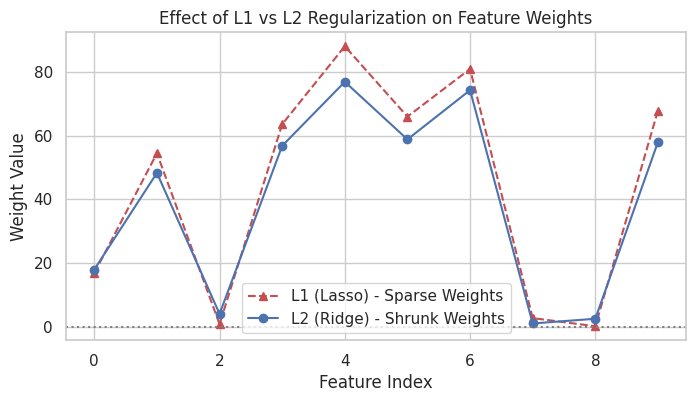

In [5]:
# Compare Unregularized vs L1 (Lasso) vs L2 (Ridge) on Regression
np.random.seed(42)
X_reg, y_reg = make_regression(n_samples=100, n_features=10, noise=15, random_state=42)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# Fit Lasso (L1) and Ridge (L2)
lasso = Lasso(alpha=2.0).fit(X_train_r, y_train_r)
ridge = Ridge(alpha=10.0).fit(X_train_r, y_train_r)

df_coef = pd.DataFrame({
    'L1 (Lasso) Coefs': lasso.coef_,
    'L2 (Ridge) Coefs': ridge.coef_
})

print("--- Coefficients Comparison ---")
print(df_coef)

plt.figure(figsize=(8, 4))
plt.plot(lasso.coef_, 'r^--', label='L1 (Lasso) - Sparse Weights')
plt.plot(ridge.coef_, 'bo-', label='L2 (Ridge) - Shrunk Weights')
plt.axhline(0, color='grey', linestyle=':')
plt.ylabel("Weight Value")
plt.xlabel("Feature Index")
plt.title("Effect of L1 vs L2 Regularization on Feature Weights")
plt.legend()
plt.show()

Bagging and boosting

In [6]:
# Compare Single Tree vs Bagging Classifier
cancer = load_breast_cancer()
X_c, y_c = cancer.data, cancer.target
X_tr, X_te, y_tr, y_te = train_test_split(X_c, y_c, test_size=0.25, random_state=42)

# Single Decision Tree
tree = DecisionTreeClassifier(random_state=42).fit(X_tr, y_tr)
# Bagging Classifier (Ensemble of trees built on bootstrap samples)
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42).fit(X_tr, y_tr)

print(f"Single Tree Test Accuracy:     {accuracy_score(y_te, tree.predict(X_te)):.4f}")
print(f"Bagging Ensemble Test Accuracy: {accuracy_score(y_te, bagging.predict(X_te)):.4f}")

Single Tree Test Accuracy:     0.9510
Bagging Ensemble Test Accuracy: 0.9580


XGBoost & LightGBM Implementations

In [7]:
# XGBoost and LightGBM Pipeline Comparison

# 1. XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    reg_alpha=0.1,   # L1 Regularization
    reg_lambda=1.0,  # L2 Regularization
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_te, y_te)],
    verbose=False
)
xgb_preds = xgb_model.predict(X_te)

# 2. LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=15,   # Important parameter for LightGBM leaf-wise growth
    reg_alpha=0.1,   # L1 Regularization
    reg_lambda=1.0,  # L2 Regularization
    random_state=42,
    verbosity=-1
)

lgb_model.fit(X_tr, y_tr)
lgb_preds = lgb_model.predict(X_te)

# Comparison Results
print("=== Performance Comparison ===")
print(f"XGBoost Test Accuracy:  {accuracy_score(y_te, xgb_preds):.4f}")
print(f"LightGBM Test Accuracy: {accuracy_score(y_te, lgb_preds):.4f}")

=== Performance Comparison ===
XGBoost Test Accuracy:  0.9580
LightGBM Test Accuracy: 0.9580


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/tmp/ipykernel_1316/4159298960.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_imp.values, y=xgb_imp.index, ax=axes[0], palette="viridis")
/tmp/ipykernel_1316/4159298960.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lgb_imp.values, y=lgb_imp.index, ax=axes[1], palette="magma")


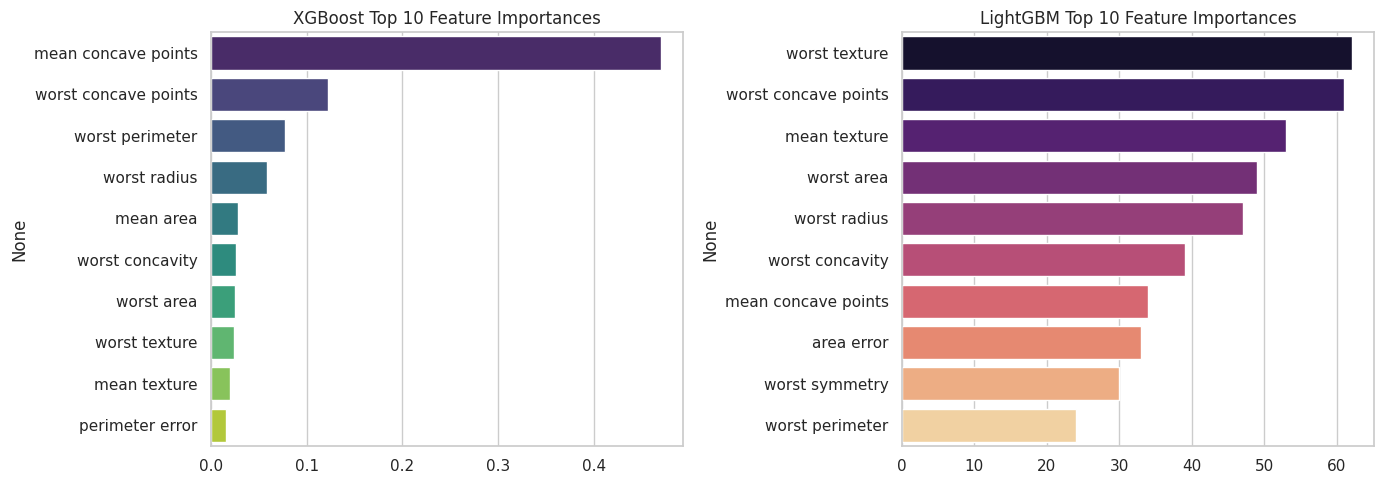

In [8]:
# Plot Feature Importances from XGBoost and LightGBM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 Features - XGBoost
xgb_imp = pd.Series(xgb_model.feature_importances_, index=cancer.feature_names).nlargest(10)
sns.barplot(x=xgb_imp.values, y=xgb_imp.index, ax=axes[0], palette="viridis")
axes[0].set_title("XGBoost Top 10 Feature Importances")

# Top 10 Features - LightGBM
lgb_imp = pd.Series(lgb_model.feature_importances_, index=cancer.feature_names).nlargest(10)
sns.barplot(x=lgb_imp.values, y=lgb_imp.index, ax=axes[1], palette="magma")
axes[1].set_title("LightGBM Top 10 Feature Importances")

plt.tight_layout()
plt.show()